# Análisis Exploratorio de Datos (EDA)
## Telco Customer Churn

### Objetivo

Realizar un análisis exploratorio del conjunto de datos Telco Customer
Churn con el propósito de comprender su estructura, evaluar su calidad,
identificar las variables disponibles y detectar patrones preliminares
relacionados con el abandono de clientes.

Esta etapa no realizará transformaciones definitivas sobre los datos.
Los hallazgos obtenidos serán utilizados posteriormente para definir
el proceso ETL y la preparación necesaria para el modelamiento.

# 1. Configuración e importación de librerías

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carga del dataset

In [15]:
import os

ruta_train = "../data/split/telco_train.csv"

df = pd.read_csv(ruta_train)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No


# 3. Exploración inicial

In [16]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5629,6308-CQRBU,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.7,No
5630,2842-JTCCU,Male,0,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),46.05,80.35,Yes
5631,6402-ZFPPI,Female,1,No,No,25,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,102.80,2660.2,Yes
5632,3594-BDSOA,Female,0,Yes,No,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.40,482.8,No
5633,6490-FGZAT,Male,0,No,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.65,109.3,No


# 4. Estructura y dimensiones del dataset

In [17]:
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 5634
Cantidad de columnas: 21


In [18]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

# 5. Tipos de datos

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  Paymen

TotalCharges esta guardado en el dataset como str, pero conceptualmente deberia ser un dato númerico

# 6. Calidad de los datos

In [20]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print("Valores vacíos por columna:")
print((df.astype(str).apply(lambda x: x.str.strip() == "")).sum())

Valores vacíos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
Churn               0
dtype: int64


*No hay variables con datos nulos pero TotalCharges presenta 8 registros vacíos representados como espacios en blanco. Estos registros corresponden a clientes con tenure = 0, por lo que deberán ser tratados durante la etapa de preparación de datos antes del modelamiento.

## TotalCharges

In [21]:
totalcharges_temp = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

print("Valores que no pudieron convertirse a numérico:",
      totalcharges_temp.isna().sum())

Valores que no pudieron convertirse a numérico: 8


In [22]:
print(
    df.loc[
        totalcharges_temp.isna(),
        ["tenure", "TotalCharges", "Churn"]
    ]
)

      tenure TotalCharges Churn
819        0                 No
1999       0                 No
2100       0                 No
4710       0                 No
5057       0                 No
5294       0                 No
5361       0                 No
5608       0                 No


TotalCharges se encuentra almacenada como texto (str) a pesar de representar una variable numérica. Los únicos registros que no pueden convertirse directamente corresponden a valores vacíos y presentan tenure = 0. Por ello, en el procesamiento se convertirá a tipo numérico y dichos casos serán tratados como 0.

In [23]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [24]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1489
TotalCharges        5276
customerID          5634
dtype: int64

Esto nos ayuda a detectar cosas como:

customerID → casi todos únicos

Churn → 2

Contract → 3

In [25]:
variables_categoricas = df.select_dtypes(include="str").columns

variables_categoricas

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [9]:
variables_numericas = df.select_dtypes(include=np.number).columns

variables_numericas

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [27]:
df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5634.0,0.163294,0.369667,0.0,0.0000,0.0,0.0,1.00
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.0,55.0,72.00
MonthlyCharges,5634.0,64.929961,30.138105,18.4,35.6625,70.5,90.0,118.75


In [11]:
variables_continuas = [
    "tenure",
    "MonthlyCharges"
]

df_temp = df.copy()

df_temp["TotalCharges"] = pd.to_numeric(
    df_temp["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

df_temp["TotalCharges"] = df_temp["TotalCharges"].fillna(0)

df_temp[variables_continuas + ["TotalCharges"]].skew()

tenure            0.237369
MonthlyCharges   -0.224363
TotalCharges      0.948972
dtype: float64

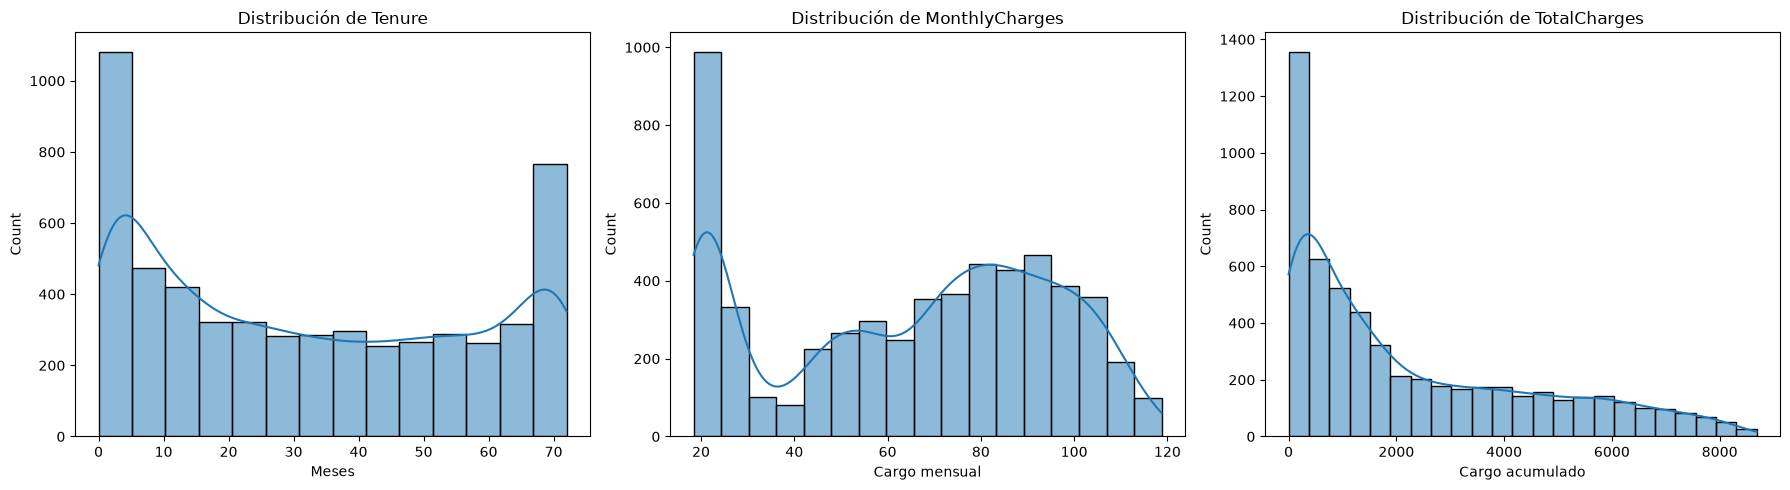

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_temp["tenure"], kde=True, ax=axes[0])
axes[0].set_title("Distribución de Tenure")
axes[0].set_xlabel("Meses")

sns.histplot(df_temp["MonthlyCharges"], kde=True, ax=axes[1])
axes[1].set_title("Distribución de MonthlyCharges")
axes[1].set_xlabel("Cargo mensual")

sns.histplot(df_temp["TotalCharges"], kde=True, ax=axes[2])
axes[2].set_title("Distribución de TotalCharges")
axes[2].set_xlabel("Cargo acumulado")

plt.tight_layout()
plt.show()

## Interpretación

tenure: Presenta una asimetría positiva leve.

MonthlyCharges: Presenta una asimetría negativa leve.

TotalCharges: Presenta una asimetría positiva más marcada.


### Hallazgo

La variable `TotalCharges` se encuentra almacenada como texto (`str`), 
aunque representa un monto monetario acumulado y debería tratarse como 
variable numérica.

Además, se identificaron 8 registros con espacios en blanco. Estos registros 
corresponden a clientes con `tenure = 0`.

### Acción para ETL

- Convertir los espacios en blanco a valores faltantes.
- Convertir `TotalCharges` a tipo numérico.
- Tratar los valores faltantes de forma reproducible dentro de la pipeline.

## SeniorCitizen

### Consideración sobre SeniorCitizen

`SeniorCitizen` presenta únicamente los valores 0 y 1, por lo que se interpreta como una variable binaria. Se mantendrá como variable numérica binaria y no se aplicará escalamiento continuo.

# 7. Variable objetivo

In [28]:
df["Churn"].value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

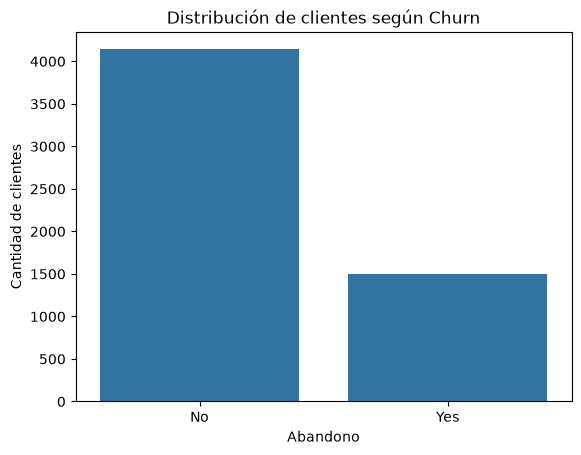

In [29]:
sns.countplot(data=df, x="Churn")

plt.title("Distribución de clientes según Churn")
plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")

plt.show()

## Nuestro primer KPI de negocio

In [30]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Tasa de abandono: {churn_rate:.2f}%")

Tasa de abandono: 26.54%


¿Qué variables parecen estar relacionadas con el abandono y cuáles podrían ser relevantes para el modelo?

In [31]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.253385,42.746615
One year,88.917306,11.082694
Two year,97.130243,2.869757


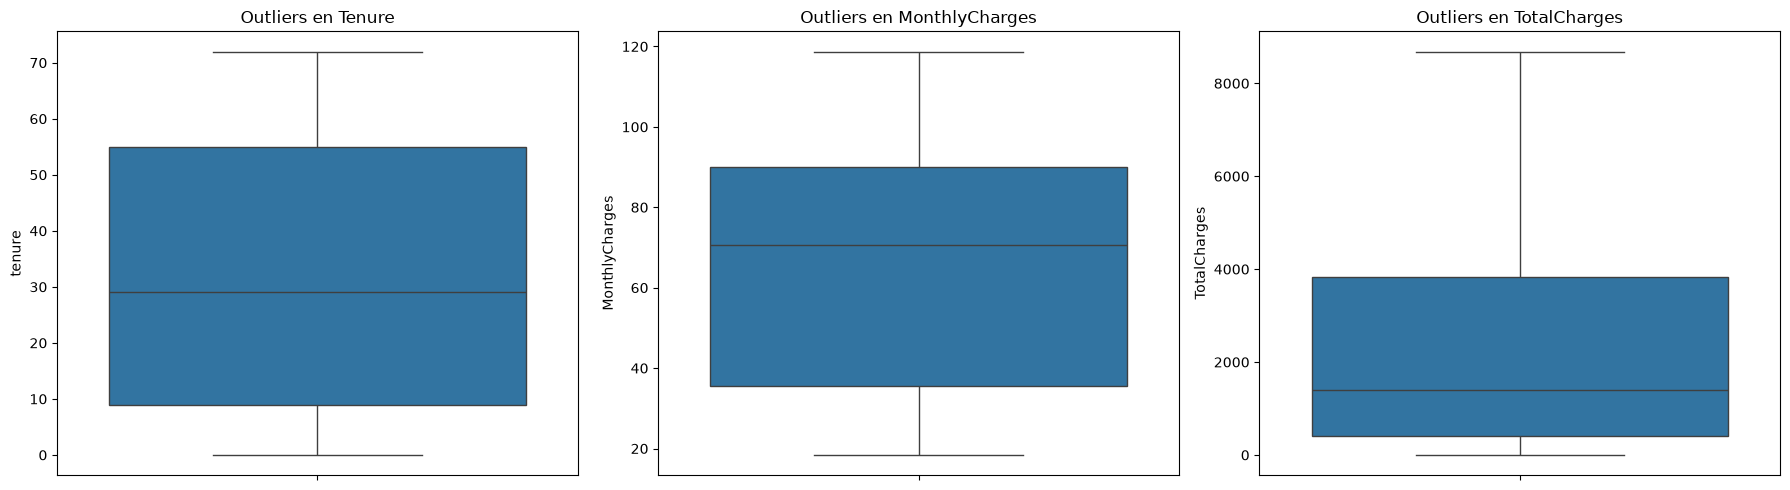

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df_temp["tenure"], ax=axes[0])
axes[0].set_title("Outliers en Tenure")

sns.boxplot(y=df_temp["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Outliers en MonthlyCharges")

sns.boxplot(y=df_temp["TotalCharges"], ax=axes[2])
axes[2].set_title("Outliers en TotalCharges")

plt.tight_layout()
plt.show()

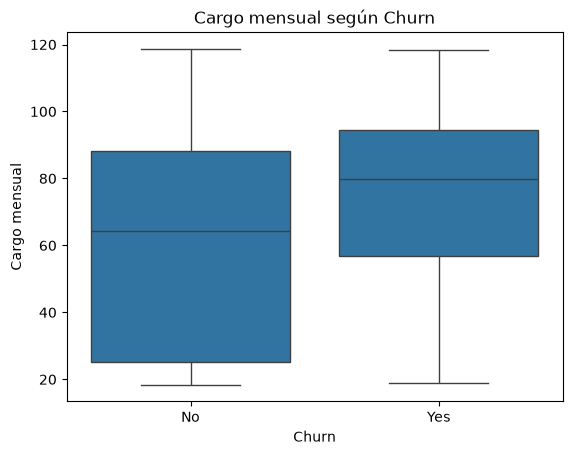

In [33]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Cargo mensual según Churn")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")

plt.show()

In [36]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.842444,16.157556
Credit card (automatic),85.078318,14.921682
Electronic check,54.257007,45.742993
Mailed check,80.715397,19.284603


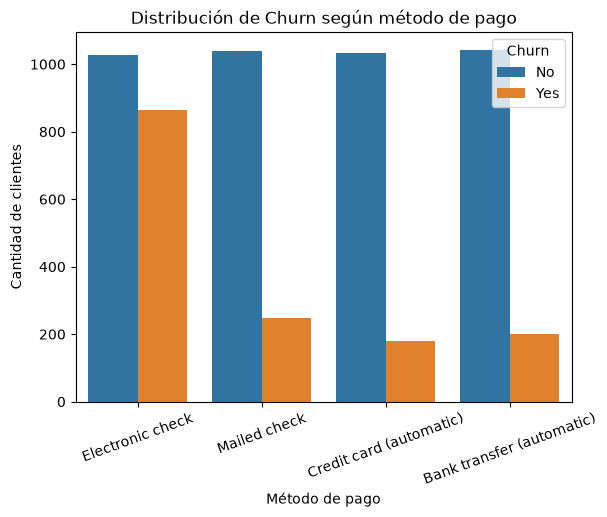

In [37]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Distribución de Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=20)
plt.show()

# 8. Clasificación de variables para el procesamiento

| Variable           | Tipo              | Decisión                       |
| ------------------ | ----------------- | ------------------------------ |
| `customerID`       | Identificador     | Excluir del modelo             |
| `Churn`            | Objetivo binario  | Codificar No=0, Yes=1          |
| `SeniorCitizen`    | Binaria           | Mantener como 0/1              |
| `tenure`           | Numérica continua | Escalar                        |
| `MonthlyCharges`   | Numérica continua | Escalar                        |
| `TotalCharges`     | Numérica continua | Convertir a numérica y escalar |
| `gender`           | Categórica        | One-Hot Encoding               |
| `Partner`          | Categórica        | One-Hot Encoding               |
| `Dependents`       | Categórica        | One-Hot Encoding               |
| `PhoneService`     | Categórica        | One-Hot Encoding               |
| `MultipleLines`    | Categórica        | One-Hot Encoding               |
| `InternetService`  | Categórica        | One-Hot Encoding               |
| `OnlineSecurity`   | Categórica        | One-Hot Encoding               |
| `OnlineBackup`     | Categórica        | One-Hot Encoding               |
| `DeviceProtection` | Categórica        | One-Hot Encoding               |
| `TechSupport`      | Categórica        | One-Hot Encoding               |
| `StreamingTV`      | Categórica        | One-Hot Encoding               |
| `StreamingMovies`  | Categórica        | One-Hot Encoding               |
| `Contract`         | Categórica        | One-Hot Encoding               |
| `PaperlessBilling` | Categórica        | One-Hot Encoding               |
| `PaymentMethod`    | Categórica        | One-Hot Encoding               |


## Decisión sobre escalamiento

El análisis exploratorio muestra que las variables numéricas continuas presentan
diferentes distribuciones y grados de asimetría. En particular, `TotalCharges`
presenta una mayor asimetría positiva que `tenure` y `MonthlyCharges`.

Por esta razón, no se utilizará `StandardScaler` de forma automática sobre todas
las variables continuas, ya que este método utiliza la media y la desviación
estándar, medidas sensibles a valores extremos.

Se utilizará `RobustScaler` para las variables numéricas continuas
(`tenure`, `MonthlyCharges` y `TotalCharges`), debido a que utiliza la mediana
y el rango intercuartílico, siendo menos sensible a valores extremos.

La variable `SeniorCitizen` se mantendrá como variable binaria 0/1 y no será
sometida a escalamiento continuo.

# 9. Conclusiones del EDA y reglas de transformación

A partir del análisis exploratorio se definieron las siguientes reglas para la
etapa de preparación de datos:

1. `customerID` corresponde a un identificador único y no se utilizará como
   variable predictora.

2. `Churn` corresponde a la variable objetivo y será codificada como:
   `No = 0` y `Yes = 1`.

3. `TotalCharges` se encuentra almacenada como texto. Será convertida a
   variable numérica.

4. Se detectaron 8 registros con `TotalCharges` vacío. Todos presentan
   `tenure = 0`, por lo que serán tratados como 0 durante la transformación.

5. Las variables categóricas serán transformadas mediante One-Hot Encoding,
   utilizando `handle_unknown='ignore'` para permitir categorías no observadas
   durante el entrenamiento.

6. `tenure`, `MonthlyCharges` y `TotalCharges` serán escaladas mediante
   `RobustScaler`, debido a la presencia de diferentes distribuciones y
   asimetría, especialmente en `TotalCharges`.

7. `SeniorCitizen` se mantendrá como variable binaria 0/1.

8. Si durante el procesamiento se detectaran otros valores faltantes, se
   utilizarán estrategias de imputación aprendidas exclusivamente a partir
   del conjunto Train.

9. El conjunto Train será utilizado para ajustar (`fit`) las transformaciones,
   mientras que Test solamente será transformado (`transform`) utilizando los
   parámetros aprendidos desde Train, evitando fuga de información.